# Gaussian Mixture Model (GMM) and Expectation-Maximization Animation

This notebook demonstrates:
1. Extracting and profiling the Iris dataset.
2. Dimensionality reduction via PCA to 2D.
3. Gaussian Mixture Model (GMM) clustering with iteration tracing of the Expectation-Maximization (EM) algorithm.
4. Generating 2D static results and a 3D likelihood surface plot.
5. Animating the EM algorithm with a high-quality GIF showing the density contours.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 43
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Minimal Exploratory Data Analysis (EDA) and PCA

We load the Iris dataset and inspect it. To simplify visualization, we scale the data using standard normalization and apply PCA to extract the two most important principal components, allowing us to trace the GMM boundaries graphically on a 2D plane.

In [9]:
# Load the dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
true_labels = iris.target
target_names = iris.target_names

# Dimensionality Reduction via PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

## 2. Iterative GMM Execution (EM Tracing)

Instead of letting `GaussianMixture` arrive at convergence silently, we initialize it using `warm_start=True` and `max_iter=1`. By running `fit` in a loop, we can incrementally collect the state parameters (`means_`, `covariances_`, and `weights_`) at every Expectation-Maximization (EM) step. This list of state history tracks exactly how the contours adapt geometrically point-by-point.

In [10]:
k = 3 # Number of clusters

# We use warm_start=True and max_iter=1 to step through the EM algorithm manually
gmm = GaussianMixture(n_components=k, max_iter=1, warm_start=True, init_params='kmeans', random_state=RANDOM_STATE)

history_means = []
history_covariances = []
history_weights = []
history_labels = []

converged = False
iteration = 0
max_iters = 50

for i in range(max_iters):
    gmm.fit(X_pca)
    
    # Save state
    history_means.append(gmm.means_.copy())
    history_covariances.append(gmm.covariances_.copy())
    history_weights.append(gmm.weights_.copy())
    history_labels.append(gmm.predict(X_pca))
    
    if gmm.converged_:
        converged = True
        iteration = i + 1
        break

print(f"GMM converged after {iteration} iterations.")
print(f"Tracked {len(history_labels)} state updates for animation.")

GMM converged after 7 iterations.
Tracked 7 state updates for animation.


## 3. Label Alignment and Accuracy Scoring

Once EM has completed, we map each final generated density cluster back onto the true species label that makes up the majority of the predicted outcomes. This enables logical model evaluation like accuracy mapping against unsupervised predictions, ensuring correct qualitative coloring.

In [11]:
final_labels = history_labels[-1]
mapped_labels = np.zeros_like(final_labels)
cluster_to_species = {}

# Two-pass assignment to ensure unique 1-to-1 species mapping
used_species = set()
for i in range(k):
    mask = (final_labels == i)
    if np.any(mask):
        most_common = np.bincount(true_labels[mask]).argmax()
        sp_name = target_names[most_common]
        if sp_name not in used_species:
            mapped_labels[mask] = most_common
            cluster_to_species[i] = sp_name
            used_species.add(sp_name)

available_species = [sp for sp in target_names if sp not in used_species]
for i in range(k):
    if i not in cluster_to_species:
        # Fallback empty or duplicate majority clusters to remaining unmapped classes
        fallback_sp = available_species.pop(0)
        cluster_to_species[i] = fallback_sp
        idx = np.where(target_names == fallback_sp)[0][0]
        mapped_labels[final_labels == i] = idx

accuracy = accuracy_score(true_labels, mapped_labels)
print(f"GMM Mapped Accuracy to True Species: {accuracy * 100:.2f}%\n")

base_colors = {'versicolor': '#1f77b4', 'setosa': '#ff7f0e', 'virginica': '#2ca02c'}
base_dark_colors = {'versicolor': '#0f3b5a', 'setosa': '#803f07', 'virginica': '#165016'}
base_light_colors = {'versicolor': '#c6dff2', 'setosa': '#ffdabd', 'virginica': '#b8f2c6'}

# Map true point colors according to their true species
true_point_colors = [base_colors[target_names[lbl]] for lbl in true_labels]

# Assign cluster colors according to majority mapped species
cluster_species = [cluster_to_species.get(i) for i in range(k)]
colors = [base_colors.get(sp) for sp in cluster_species]
dark_colors = [base_dark_colors.get(sp) for sp in cluster_species]
light_colors_list = [base_light_colors.get(sp) for sp in cluster_species]

GMM Mapped Accuracy to True Species: 89.33%



## 4. Model Evaluation Visualization (Confusion Matrix)

To visualize the accuracy of our GMM clustering against the true species labels, we generate a confusion matrix. This illustrates how many points were correctly assigned to their true species based on the cluster's majority mapping, highlighting where the unsupervised model struggled to differentiate overlapping classes.

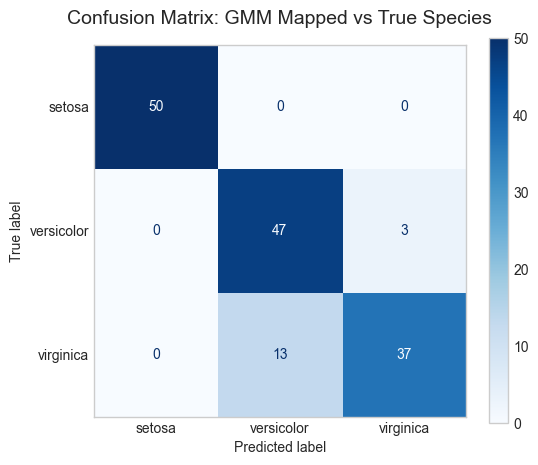

In [12]:
fig, ax_cm = plt.subplots(figsize=(6, 5), dpi=100)
ax_cm.set_facecolor('white')
fig.patch.set_facecolor('white')

# Generate and display the confusion matrix
cm = confusion_matrix(true_labels, mapped_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap='Blues', values_format='d', ax=ax_cm)
ax_cm.set_title("Confusion Matrix: GMM Mapped vs True Species", fontsize=14, pad=15)
ax_cm.grid(False) # Turn off grid for the matrix visualization

plt.show()

## 5. Internal 3D Visualization (Landscape Plot)

To emphasize the dimensionality of probabilities, we overlay the three `multivariate_normal` mixtures and plot their combined probabilities cumulatively scaled by mixture components `weights_`! This generates an interactive 3D terrain representation rendering GMM behavior organically.

In [22]:
import plotly.graph_objects as go
import numpy as np

# Create a wider meshgrid to ensure the entire base and all tails of the distributions are visible
x_min, x_max = X_pca[:, 0].min() - 2, X_pca[:, 0].max() + 2
y_min, y_max = X_pca[:, 1].min() - 2, X_pca[:, 1].max() + 2
# Increase resolution for a perfectly smooth surface
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
pos = np.dstack((xx, yy))

# Calculate raw densities for each component
Z_components = np.array([gmm.weights_[i] * multivariate_normal(gmm.means_[i], gmm.covariances_[i]).pdf(pos) for i in range(k)])

# Get the maximum density to form the landscape without blending/clipping components
Z = np.max(Z_components, axis=0)

# Determine which component dominates at each point to assign custom colors
max_component_idx = np.argmax(Z_components, axis=0)
surfacecolor = np.zeros_like(Z)
custom_colorscale = []

for i in range(k):
    # Normalize density of the current component to range [0, 1]
    Z_i = Z_components[i]
    Z_norm = (Z_i - Z_i.min()) / (Z_i.max() - Z_i.min() + 1e-9)
    
    # Shift values to [i, i+1] for the Plotly colorscale mapping
    mask = (max_component_idx == i)
    surfacecolor[mask] = i + Z_norm[mask]
    
    # Create the gradient from light color (base) to true color (peak) for the active component
    custom_colorscale.append([i / k, light_colors_list[i]])
    custom_colorscale.append([(i + 1) / k, colors[i]])

# Create an interactive 3D surface plot using Plotly
# opacity=1.0 is crucial. It completely eliminates the WebGL depth-sorting glitches
# that cause transparent objects to clip incorrectly when rotated!
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=xx, 
    y=yy, 
    surfacecolor=surfacecolor,
    cmin=0,
    cmax=k,
    colorscale=custom_colorscale, 
    showscale=False, # Disable general color bar since each hill has a totally different scale
    opacity=1.0,
    contours=dict(
        x=dict(highlight=False), # Turn off hover highlighting contours
        y=dict(highlight=False),
        z=dict(show=False, highlight=False)
    )
)])

fig.update_layout(
    title={
        'text': 'Interactive 3D Kernel Density Plot of GMM Components',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 18}
    },
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Probability Density',
        camera=dict(eye=dict(x=-1.5, y=-1.5, z=0.8)),
        aspectratio=dict(x=1, y=1, z=0.6) # Balance the Z-axis to make peaks prominent
    ),
    autosize=True,
    margin=dict(l=0, r=0, b=0, t=50) # Tightly bound to take as much space as possible
)

fig.show()

## 6. Generating the Expectation-Maximization Gradient GIF

An iterative view brings transparency to parameter expansion loop over clusters! `FuncAnimation` sweeps directly through our tracking arrays (incorporating `history_covariances` to scale/stretch dimensions naturally) showing EM gradient expansions until cluster boundaries equilibrate.

In [16]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(9, 7), dpi=120)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_title("GMM Expectation-Maximization Iterations", fontsize=16, fontweight='bold', pad=20)

scatter_points = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=true_point_colors, s=45, alpha=0.9, edgecolors='k', zorder=5)
scatter_cents = ax.scatter(history_means[0][:, 0], history_means[0][:, 1], c=dark_colors, marker='X', s=250, edgecolors='white', linewidths=2, zorder=15)

legend_patches = [Patch(facecolor=colors[i], edgecolor=dark_colors[i], label=cluster_species[i]) for i in range(k)]
ax.legend(handles=legend_patches, title="Species Mapping", loc='upper left', frameon=True, facecolor='white', framealpha=0.9).set_zorder(20)
title_text = ax.text(0.5, 0.98, '', transform=ax.transAxes, ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', zorder=20))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC', zorder=1)

state = {'contours': []}
spider_lines = []
arrows = []

def clear_contours():
    for c in state['contours']:
        try:
            c.remove()
        except AttributeError:
            for coll in c.collections:
                try: coll.remove()
                except: pass
    state['contours'] = []

def clear_spider_lines():
    while spider_lines:
        ln = spider_lines.pop()
        ln.remove()
        
def clear_arrows():
    while arrows:
        arr = arrows.pop()
        arr.remove()

def init():
    scatter_cents.set_offsets(history_means[0])
    title_text.set_text('')
    clear_contours()
    clear_spider_lines()
    clear_arrows()
    return scatter_points, scatter_cents, title_text

def animate(frame):
    frame_idx = min(frame, len(history_labels) - 1)
    curr_means = history_means[frame_idx]
    curr_covs = history_covariances[frame_idx]
    curr_labels = history_labels[frame_idx]
    
    clear_contours()
    clear_spider_lines()
    clear_arrows()

    # Draw expanding gradient contours fading to transparent white
    for i in range(k):
        try:
            rv = multivariate_normal(curr_means[i], curr_covs[i])
            cmap = mcolors.LinearSegmentedColormap.from_list(f'cmap_{i}', ['#ffffff00', colors[i]])
            cont = ax.contourf(xx, yy, rv.pdf(pos), levels=15, cmap=cmap, zorder=0)
            state['contours'].append(cont)
        except np.linalg.LinAlgError:
            pass # Skip ill-conditioned contours dynamically
        
        # Add spider lines from each point to its currently assigned center
        cluster_mask = (curr_labels == i)
        cluster_pts = X_pca[cluster_mask]
        cent_pt = curr_means[i]
        for pt in cluster_pts:
            ln, = ax.plot([cent_pt[0], pt[0]], [cent_pt[1], pt[1]], color=dark_colors[i], linewidth=0.6, alpha=0.35, zorder=4)
            spider_lines.append(ln)
            
    scatter_cents.set_offsets(curr_means)
    
    # Movement arrows
    if frame_idx > 0:
        prev_means = history_means[frame_idx - 1]
        for p_cent, c_cent in zip(prev_means, curr_means):
            arr = ax.annotate('', xy=c_cent, xytext=p_cent, arrowprops=dict(arrowstyle="->", color='#333333', lw=2, alpha=0.8, shrinkA=0, shrinkB=0), zorder=10)
            arrows.append(arr)
            
    title_text.set_text(f"EM Iteration: {frame_idx + 1} / {len(history_labels)}")
    return []

total_frames = len(history_labels) + 2
anim = FuncAnimation(fig, animate, init_func=init, frames=total_frames, interval=1000, blit=False)
gif_path = os.path.abspath(os.path.join('..', 'animations', 'gmm_em_animation.gif'))
os.makedirs(os.path.dirname(gif_path), exist_ok=True)
anim.save(gif_path, dpi=120, writer=PillowWriter(fps=1.0))
plt.close(fig)

print(f"Successfully saved GMM EM animation to: {gif_path}")

Successfully saved GMM EM animation to: d:\Git-Projects\clustering-algorithms\animations\gmm_em_animation.gif
